In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Подготовка данных

## Отдельные датафреймы

### Смещения

In [3]:
def takefirst7(x): # функции для приведения к общему виду
    return x[:7]

def takefirst10(x): # функции для приведения к общему виду
    return x[:10]

df_DM_moving_old = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Перемещения") # берем старые названия столбцов
df_DM_moving = pd.read_excel("new_data.xlsx", sheet_name= "ДМ_перемещения приростом")
print(df_DM_moving_old.columns)
df_DM_moving.columns = [*df_DM_moving_old.columns, 'XIII']  # Заменяем названия столбцов
df_DM_moving = df_DM_moving.drop(0)

new_columns = {
    'Объект': 'Site',
    'Номер ДМ': 'Mark_num',
    'Имя ДМ': 'Mark_name',
}

# порядок месяцев
base_cols = ["Объект", "Участок", "Номер ДМ", "Имя ДМ"]
months = ["II","III","IV","V","VI","VII","VIII","IX","X","XI","XII"]
months_rev = months[::-1] # развернём порядок (от большего к меньшему)

window_size = 4 # размер окна 

results = []

for i in range(len(months_rev) - window_size + 1):
    
    cols = months_rev[i:i+window_size]
    
    temp = df_DM_moving[base_cols + cols].copy()

    current_cyc = months_rev[i]  # берем первый месяц текущего окна
    temp['Цикл'] = current_cyc  # добавляем в каждую строку

    temp.rename(columns=dict(zip(cols, ["di","di-1","di-2","di-3"])), inplace=True)
    
    results.append(temp)

# объединяем в один датафрейм
final_df = pd.concat(results, ignore_index=True)

df_DM_moving = final_df.rename(columns = new_columns).dropna()

df_DM_moving['Site'] = df_DM_moving['Site'].apply(takefirst7)
df_DM_moving['Участок'] = df_DM_moving['Участок'].apply(takefirst10)

df_DM_moving

Index(['Объект', 'Участок', 'Номер ДМ', 'Имя ДМ', 'II', 'III', 'IV', 'V', 'VI',
       'VII', 'VIII', 'IX', 'X', 'XI', 'XII'],
      dtype='object')


,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,Цикл
0,ГТМ.021,ГТМ.021.01,ДМ.014492,20.198a,10.2,8.5,9.6,8.4,XII
1,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,3.7,-3.2,-2.1,1.2,XII
2,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,3.1,9.4,0.9,-0.8,XII
3,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,7.6,-2.6,-3,-3.5,XII
4,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,-0.6,-2.5,-2.4,-5.3,XII
...,...,...,...,...,...,...,...,...,...
152683,ГТМ.014,ГТМ.014.01,ДМ.011419,skv13-4,4.2,5.1,4.7,4.3,V
152684,ГТМ.018,ГТМ.018.01,ДМ.013088,skv17-3,1.8,5.7,-6.1,0.8,V
152685,ГТМ.019,ГТМ.019.01,ДМ.013542,skv18-2,2.1,-2.3,3,2.1,V
152686,ГТМ.021,ГТМ.021.01,ДМ.014289,skv20-3,-11.4,-5.8,-3.3,-3.4,V


In [7]:
names_di_columns = ['di']
for num in range(4):
    if num > 0:
        names_di_columns.append(f'di-{num}')
names_di_columns

['di', 'di-1', 'di-2', 'di-3']

In [ ]:
cols = ['di', 'di-1', 'di-2', 'di-3'] # убираем выбросы путем поиска слишком сильных скачков, считаем их за погрешность

# считаем максимальную разницу между соседними значениями
diff = df_DM_moving[cols].diff(axis=1).abs()

# порог выброса
threshold = 12

# строки без сильных скачков
df_DM_moving = df_DM_moving[diff.max(axis=1) < threshold]
df_DM_moving

,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,Цикл
0,ГТМ.021,ГТМ.021.01,ДМ.014492,20.198a,10.2,8.5,9.6,8.4,XII
1,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,3.7,-3.2,-2.1,1.2,XII
2,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,3.1,9.4,0.9,-0.8,XII
3,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,7.6,-2.6,-3,-3.5,XII
4,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,-0.6,-2.5,-2.4,-5.3,XII
...,...,...,...,...,...,...,...,...,...
152683,ГТМ.014,ГТМ.014.01,ДМ.011419,skv13-4,4.2,5.1,4.7,4.3,V
152684,ГТМ.018,ГТМ.018.01,ДМ.013088,skv17-3,1.8,5.7,-6.1,0.8,V
152685,ГТМ.019,ГТМ.019.01,ДМ.013542,skv18-2,2.1,-2.3,3,2.1,V
152686,ГТМ.021,ГТМ.021.01,ДМ.014289,skv20-3,-11.4,-5.8,-3.3,-3.4,V


In [ ]:
# удаляем выбросы квантильным размахом (не использовалось в лучше итерации)

cols = ['di','di-1','di-2','di-3']

low = df_DM_moving[cols].quantile(0.02)
high = df_DM_moving[cols].quantile(0.98)

a = df_DM_moving[
    (df_DM_moving[cols] >= low).all(axis=1) &
    (df_DM_moving[cols] <= high).all(axis=1)
]



print(a['di'].max())
print(a['di-1'].max())
print(a['di-2'].max())
print(a['di-3'].max())

df_DM_moving = a.copy()
df_DM_moving

19.1
17.7
16.4
15.2


,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,Цикл
0,ГТМ.021,ГТМ.021.01,ДМ.014492,20.198a,10.2,8.5,9.6,8.4,XII
1,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,3.7,-3.2,-2.1,1.2,XII
2,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,3.1,9.4,0.9,-0.8,XII
3,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,7.6,-2.6,-3,-3.5,XII
4,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,-0.6,-2.5,-2.4,-5.3,XII
...,...,...,...,...,...,...,...,...,...
152683,ГТМ.014,ГТМ.014.01,ДМ.011419,skv13-4,4.2,5.1,4.7,4.3,V
152684,ГТМ.018,ГТМ.018.01,ДМ.013088,skv17-3,1.8,5.7,-6.1,0.8,V
152685,ГТМ.019,ГТМ.019.01,ДМ.013542,skv18-2,2.1,-2.3,3,2.1,V
152686,ГТМ.021,ГТМ.021.01,ДМ.014289,skv20-3,-11.4,-5.8,-3.3,-3.4,V


### Ближайшие ТС

,Site,Участок,Mark_num,Mark_name,TS_num,TS_name,Distance
0,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,ТС.000089,31.64,3.435
1,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,ТС.000089,31.64,4.669
2,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,ТС.000089,31.64,2.503
3,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,ТС.000089,31.64,4.023
4,ГТМ.001,ГТМ.001.01,ДМ.000005,e1.5,ТС.000089,31.64,2.501
...,...,...,...,...,...,...,...
116544,ГТМ.036,ГТМ.036.10,ДМ.020767,pk.10,ТС.001722,ТС-P11,30.383
116545,ГТМ.036,ГТМ.036.10,ДМ.020767,pk.10,ТС.001719,ТС-P8н,39.665
116546,ГТМ.036,ГТМ.036.10,ДМ.020767,pk.10,ТС.001717,ТС-P6,43.766
116547,ГТМ.036,ГТМ.036.10,ДМ.020767,pk.10,ТС.001720,ТС-P9,46.636


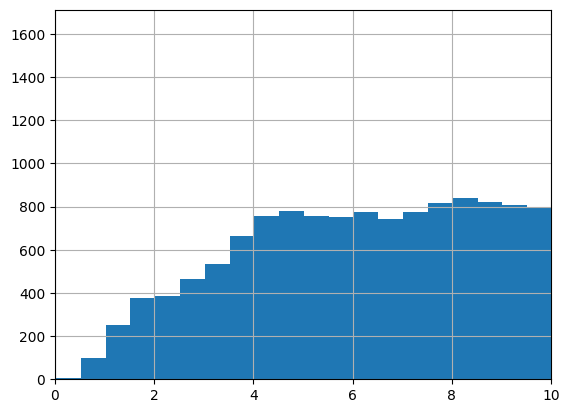

In [88]:
df_closestTS_new = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Ближайшие ТС_new")
new_columns = {
    'Номер ТС': 'TS_num',
    'Объект': 'Site',
    'Имя ТС': 'TS_name',
    'Расстояние (метры)': 'Distance',
    'Номер ДМ': 'Mark_num',
    'Имя ДМ': 'Mark_name'
}

df_closestTS_new = df_closestTS_new.drop(['Ранг'], axis = 1).dropna()
df_closestTS_new = df_closestTS_new[df_closestTS_new['Расстояние (метры)'] <= 50] # берем только значения <= 50 метров
df_closestTS_new = df_closestTS_new.rename(columns = new_columns)


df_closestTS_new['Distance'].hist(bins=100)
plt.xlim([0,10])
df_closestTS_new

### Тип почвы

In [18]:
df_columns_new = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Колонки_new")

new_columns = {
    'Номер ТС': 'TS_num',
    'Вид грунта 0': 'SoilType_0',
    'Вид грунта 0.5': 'SoilType_05',
    'Вид грунта 1': 'SoilType_1',
    'Вид грунта 1.5': 'SoilType_15',
    'Вид грунта 2': 'SoilType_2',
    'Вид грунта 2.5': 'SoilType_25',
    'Вид грунта 3': 'SoilType_3',
    'Вид грунта 3.5': 'SoilType_35',
    'Вид грунта 4': 'SoilType_4',
    'Вид грунта 4.5': 'SoilType_45',
    'Вид грунта 5': 'SoilType_5',
    'Вид грунта 6': 'SoilType_6',
    'Вид грунта 7': 'SoilType_7',
    'Вид грунта 8': 'SoilType_8',
    'Вид грунта 9': 'SoilType_9',
    'Вид грунта 10': 'SoilType_10'
}


df_columns_new = df_columns_new.drop(['Колонка16', 'Колонка10'], axis=1).dropna()
df_columns_new = df_columns_new.rename(columns=new_columns)
df_columns_new

,TS_num,SoilType_0,SoilType_05,SoilType_1,SoilType_15,SoilType_2,SoilType_25,SoilType_3,SoilType_35,SoilType_4,SoilType_45,SoilType_5,SoilType_6,SoilType_7,SoilType_8,SoilType_9,SoilType_10
0,ТС.000026,1,1,1,1,1,4,3,3,3,3,3,3,3,3,3,3
1,ТС.000027,1,1,1,1,4,2,2,2,2,2,2,2,2,3,3,3
2,ТС.000028,1,1,1,1,4,2,2,2,2,2,2,2,2,3,3,3
3,ТС.000029,1,1,1,1,4,3,3,2,2,2,2,2,2,3,3,3
4,ТС.000030,1,1,1,1,4,3,3,2,2,2,2,2,2,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,ТС.000023,1,1,1,1,1,1,1,4,4,3,3,3,2,2,2,2
1298,ТС.000024,1,1,1,1,1,1,1,4,4,3,3,3,2,2,2,2
1299,ТС.000025,1,1,1,1,1,1,1,4,4,3,3,3,2,2,2,2
1300,ТС.001222,1,1,1,1,1,6,2,2,4,4,4,4,0,0,0,0


### Температура

In [19]:
df_temp_new = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Температура_new")
new_columns = {
    'Номер ТС': 'TS_num',
    '0': 'temp_0',
    '0.5': 'temp_05',
    '1': 'temp_1',
    '1.5': 'temp_15',
    '2': 'temp_2',
    '2.5': 'temp_25',
    '3': 'temp_3',
    '3.5': 'temp_35',
    '4': 'temp_4',
    '4.5': 'temp_45',
    '5': 'temp_5',
    '6': 'temp_6',
    '7': 'temp_7',
    '8': 'temp_8',
    '9': 'temp_9',
    '10': 'temp_10',
    'Тср,°C (3.0-10.0 м)': 'tai'
}

roman_to_int = {
    'I':1,'II':2,'III':3,'IV':4,'V':5,'VI':6,
    'VII':7,'VIII':8,'IX':9,'X':10,'XI':11,'XII':12, 'XIII':13
}

int_to_roman = {v:k for k,v in roman_to_int.items()}

df_temp_new["Цикл"] = df_temp_new["Цикл"].map(roman_to_int) + 1
df_temp_new["Цикл"] = df_temp_new["Цикл"].map(int_to_roman)

# df_temp_new = df_temp_new[df_temp_new['Цикл'].isin(['X', 'XI', 'XII'])].dropna() # берем только 3 последних цикла
df_temp_new = df_temp_new.rename(columns=new_columns) # Применяем переименование
df_temp_new = df_temp_new.drop(['temp_0', 'temp_05', 'temp_1', 'temp_15', 'temp_2', 'temp_25', 'temp_3', 'temp_35', 'temp_4', 'temp_45', 'temp_5'], 
                                axis =1)

df_temp_new = df_temp_new[df_temp_new['Цикл'] != 'XIII']
df_temp_new

,TS_num,Цикл,temp_6,temp_7,temp_8,temp_9,temp_10,tai
0,ТС.000020,V,1.25,1.25,1.19,1.44,1.31,1.81
1,ТС.000020,II,1.32,1.19,0.96,0.68,0.47,1.20
2,ТС.000020,III,3.45,3.14,2.85,2.41,2.01,3.58
3,ТС.000020,VII,NaN,NaN,NaN,NaN,NaN,NaN
4,ТС.000020,IX,0.71,0.82,0.97,1.03,1.11,0.62
...,...,...,...,...,...,...,...,...
15600,ТС.001841,XII,2.37,1.79,1.47,1.27,1.04,2.90
15602,ТС.001841,NaN,2.67,1.94,1.67,1.46,1.14,3.50
15604,ТС.001842,NaN,0.70,0.89,0.85,0.84,0.78,0.40
15605,ТС.001846,XI,0.40,0.40,0.30,0.30,0.20,0.20


### Климат

In [20]:
# Климат для df_temp_old и df_temp_new
df_climat = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Климат")

df_climat = df_climat.T # Переворачиваем
df_climat.reset_index(inplace=True) # Вытаскиваем индексы потому что там теперь период
df_climat.columns = ["Цикл", "snowi", "preci", "tempi"] 
df_climat = df_climat[1::]
df_climat = df_climat.reset_index(drop=True) # обновления индексации строк

roman_to_int = {
    'I':1,'II':2,'III':3,'IV':4,'V':5,'VI':6,
    'VII':7,'VIII':8,'IX':9,'X':10,'XI':11,'XII':12, 'XIII':13
}

int_to_roman = {v:k for k,v in roman_to_int.items()}

df_climat


,Цикл,snowi,preci,tempi
0,I,14.0,347.4,9.36969
1,II,62.553991,216.8,-11.62691
2,III,2.772727,288.5,11.193056
3,IV,43.353774,176.4,-17.982773
4,V,1.810458,434.2,8.919363
5,VI,46.768868,212.6,-15.021698
6,VII,4.888889,305.1,10.505569
7,VIII,44.830189,175.0,-15.525118
8,IX,9.662338,230.6,10.215686
9,X,39.981221,189.2,-15.524002


### Создание заболоченности

In [ ]:
# Состояние заболоченности
# df_swamp_status = pd.read_excel(r"C:\Users\faire\OneDrive\Desktop\Заболоченность_да_нет_согласованный.xlsx", sheet_name="Лист1")
# 0 - не заболоченная
# 1 - на половину
# 2 - заболоченная

df_swamp_status.drop(columns=["Unnamed: 0", "Unnamed: 3", "Unnamed: 4" ], inplace = True) # Убираем лишние столбцы
df_swamp_status = df_swamp_status[5::] # Шапку скипаем
df_swamp_status.columns = ['Site', 'Участок',"Swamp"] # нам нужны только стобцы объекта и статус заболоченности (и участок)
df_swamp_status["Site"] = df_swamp_status["Site"].apply(lambda x: x[:7]) # отрезаем первые 7 символов в первом столбце, чтобы объядинить с DM

df_swamp_status.loc[25, "Site"] = "ГТМ.018" # почему-то в таблице он пропущен, хотя изображения есть !ПРОВЕРЬТЕ, ЕСЛИ ЧТО УДАЛИТЬ

df_swamp_status.loc[df_swamp_status['Swamp'] == 'Нет', 'Swamp'] = 0 # не заболченная территория
df_swamp_status.loc[df_swamp_status['Swamp'] == 'нет', 'Swamp'] = 0 # не заболченная территория
df_swamp_status.loc[df_swamp_status['Swamp'] == 'Скорее нет', 'Swamp'] = 0 # не заболченная территория
df_swamp_status.loc[df_swamp_status['Swamp'] == 'да', 'Swamp'] = 2 # Заболченная территория
df_swamp_status['Swamp'] = df_swamp_status['Swamp'].apply(lambda x: 1 if isinstance(x, str) else x) # все что осталось делаем 1, это вариант что-то между
df_swamp_status = df_swamp_status.reset_index(drop=True) # обновления индексации строк



df_swamp_status['Участок'] = df_swamp_status['Участок'].str.split().str[0]

df_swamp_status.loc[:34, 'Участок'] = ( # создаем наименования для столбца Участок (по нему и будем делать merge)
    df_swamp_status.loc[:34, 'Site'] + '.' +  (df_swamp_status.loc[:34].groupby('Site').cumcount() + 1).astype(str).str.zfill(2)
)


df_swamp_status = df_swamp_status.drop('Site', axis =1) # Оставляем только уникальные значения Участка, остальное удаляем

# df_swamp_status.to_csv('Заболоченность.csv')

df_swamp_status

In [20]:
temp_cols = [
            [f'temp_{d}_{lag}' for d in ['6','7','8','9','10']] 
            for lag in list(range(3 + 1))[1:]
        ]

for num in range(3):   
    temp_cols.append(f'snowi_{num+1}')
    temp_cols.append(f'preci_{num+1}')
    temp_cols.append(f'tempi_{num+1}')

temp_cols

[['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'],
 ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'],
 ['temp_6_3', 'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3'],
 'snowi_1',
 'preci_1',
 'tempi_1',
 'snowi_2',
 'preci_2',
 'tempi_2',
 'snowi_3',
 'preci_3',
 'tempi_3']

In [ ]:

temp_cols

### Чтение заболоченности

In [22]:
df_swamp_status = pd.read_csv(r"Заболоченность.csv").drop("Unnamed: 0", axis = 1)

### Тип сооружения

In [23]:
df_btype = pd.read_excel("Все параметры_12 циклов_new_26.12.xlsx", sheet_name="Тип сооружения")
df_btype['Тип сооружения'] = df_btype['Тип сооружения'].apply(lambda x: 0 if x == 'Линейное' else 1) # 0 если Линейное, 1 если нелинейнное
df_btype.columns = ['Mark_num', 'Geometry']
df_btype

,Mark_num,Geometry
0,ДМ.014492,1
1,ДМ.000001,0
2,ДМ.000002,0
3,ДМ.000003,0
4,ДМ.000004,0
...,...,...
19097,ДМ.020763,0
19098,ДМ.020764,0
19099,ДМ.020765,0
19100,ДМ.020766,0


## ОБЪЕДИНЕНИЕ данных

### Создание tempi-1, tempi-2 и т.д.

In [89]:
# Слияние датафреймов и базовая обработка
tmp = df_temp_new.merge(
    right=df_climat, 
    on='Цикл', 
    how='left'
).drop(['tai'], axis =1)



# Сохранение колонок
cols = tmp.columns

# Установка порядка для категориального столбца
order = ['I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII']
tmp['Цикл'] = pd.Categorical(
    tmp['Цикл'],
    categories=order,
    ordered=True
)

# Определение признаков для сдвига
features = tmp.columns.drop(['TS_num', 'Цикл'])

# Добавляем суффикс -1 к исходным столбцам
original_features = features.tolist()

tmp = tmp.sort_values(['TS_num', 'Цикл'])

# Создание лагов -2 и -3
for lag in [1, 2]:
    shifted = (
        tmp.groupby('TS_num')[features].shift(lag).add_suffix(f'_{lag+1}')  # добавляем суффиксы -2 и -3
    )
    tmp = pd.concat([tmp, shifted], axis=1)

tmp = tmp.rename(columns={col: f"{col}_1" for col in original_features})

# Финальная обработка
df_temp_newi = tmp.reset_index(drop=True)
df_temp_newi

,TS_num,Цикл,temp_6_1,temp_7_1,temp_8_1,temp_9_1,temp_10_1,snowi_1,preci_1,tempi_1,...,preci_2,tempi_2,temp_6_3,temp_7_3,temp_8_3,temp_9_3,temp_10_3,snowi_3,preci_3,tempi_3
0,ТС.000020,II,1.32,1.19,0.96,0.68,0.47,62.553991,216.8,-11.62691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ТС.000020,III,3.45,3.14,2.85,2.41,2.01,2.772727,288.5,11.193056,...,216.8,-11.62691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ТС.000020,IV,2.94,2.39,1.81,1.30,0.97,43.353774,176.4,-17.982773,...,288.5,11.193056,1.32,1.19,0.96,0.68,0.47,62.553991,216.8,-11.62691
3,ТС.000020,V,1.25,1.25,1.19,1.44,1.31,1.810458,434.2,8.919363,...,176.4,-17.982773,3.45,3.14,2.85,2.41,2.01,2.772727,288.5,11.193056
4,ТС.000020,VI,2.15,1.71,1.40,1.23,1.06,46.768868,212.6,-15.021698,...,434.2,8.919363,2.94,2.39,1.81,1.30,0.97,43.353774,176.4,-17.982773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14348,ТС.001841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,252.3,-12.500649,0.52,0.18,-0.03,-0.09,-0.06,72.042654,252.3,-12.500649
14349,ТС.001841,NaN,2.67,1.94,1.67,1.46,1.14,NaN,NaN,NaN,...,NaN,NaN,2.37,1.79,1.47,1.27,1.04,72.042654,252.3,-12.500649
14350,ТС.001842,NaN,0.70,0.89,0.85,0.84,0.78,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14351,ТС.001846,XI,0.40,0.40,0.30,0.30,0.20,15.699346,212.7,8.826225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
list(range(1,3))

[1, 2]

### Объединение дистанции ТипыПочвНаГлубине температуры

In [90]:
df_closestTS_newi = df_temp_newi.merge(df_columns_new,  on = 'TS_num', how = 'left')
# df_closestTS_newi

### Объединение смещений болотистости и типа строения

In [91]:
df_DM_movingi = df_DM_moving.merge(right = df_swamp_status, on = 'Участок', how = 'left')
# df_DM_movingi

### Фильтрация df_closestTS

In [92]:
df_closestTS_unique = df_closestTS_new.loc[ # Оставляем только один TS_name на Mark_num (СОРТИРУЕМ ПО Distance)
    df_closestTS_new.groupby("Mark_num")["Distance"].idxmin()
]

# df_closestTS_unique

### Финальные объединения

In [93]:
df1 = df_DM_movingi.merge(df_closestTS_unique[['Mark_num', 'TS_num', 'Distance']], how = 'left') # 516 уникальных ТС
df1 = df1.merge(df_btype, on = "Mark_num", how = "left") # добавляем Тип здания

df1

,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,Цикл,Swamp,TS_num,Distance,Geometry
0,ГТМ.021,ГТМ.021.01,ДМ.014492,20.198a,10.2,8.5,9.6,8.4,XII,0,ТС.001051,4.329,1.0
1,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,3.7,-3.2,-2.1,1.2,XII,0,ТС.000089,3.435,0.0
2,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,3.1,9.4,0.9,-0.8,XII,0,ТС.000089,4.669,0.0
3,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,7.6,-2.6,-3,-3.5,XII,0,ТС.000089,2.503,0.0
4,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,-0.6,-2.5,-2.4,-5.3,XII,0,ТС.000089,4.023,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121717,ГТМ.014,ГТМ.014.01,ДМ.011419,skv13-4,4.2,5.1,4.7,4.3,V,0,ТС.000778,7.275,1.0
121718,ГТМ.018,ГТМ.018.01,ДМ.013088,skv17-3,1.8,5.7,-6.1,0.8,V,0,ТС.000952,9.124,1.0
121719,ГТМ.019,ГТМ.019.01,ДМ.013542,skv18-2,2.1,-2.3,3,2.1,V,0,ТС.000980,11.079,1.0
121720,ГТМ.021,ГТМ.021.01,ДМ.014289,skv20-3,-11.4,-5.8,-3.3,-3.4,V,0,ТС.001055,6.352,1.0


In [94]:
final_df = df1.merge(df_closestTS_newi, on=['TS_num','Цикл'], how='left')
# final_df

In [95]:
final_df.Цикл.unique()

array(['XII', 'XI', 'X', 'IX', 'VIII', 'VII', 'VI', 'V'], dtype=object)

In [96]:
final_df.dropna()

,Site,Участок,Mark_num,Mark_name,di,di-1,di-2,di-3,Цикл,Swamp,...,SoilType_3,SoilType_35,SoilType_4,SoilType_45,SoilType_5,SoilType_6,SoilType_7,SoilType_8,SoilType_9,SoilType_10
1,ГТМ.001,ГТМ.001.01,ДМ.000001,e1.1,3.7,-3.2,-2.1,1.2,XII,0,...,2.0,2.0,2.0,2.0,2.0,5.0,5.0,4.0,5.0,5.0
2,ГТМ.001,ГТМ.001.01,ДМ.000002,e1.2,3.1,9.4,0.9,-0.8,XII,0,...,2.0,2.0,2.0,2.0,2.0,5.0,5.0,4.0,5.0,5.0
3,ГТМ.001,ГТМ.001.01,ДМ.000003,e1.3,7.6,-2.6,-3,-3.5,XII,0,...,2.0,2.0,2.0,2.0,2.0,5.0,5.0,4.0,5.0,5.0
4,ГТМ.001,ГТМ.001.01,ДМ.000004,e1.4,-0.6,-2.5,-2.4,-5.3,XII,0,...,2.0,2.0,2.0,2.0,2.0,5.0,5.0,4.0,5.0,5.0
5,ГТМ.001,ГТМ.001.01,ДМ.000005,e1.5,0.8,-3.6,-3,-5,XII,0,...,2.0,2.0,2.0,2.0,2.0,5.0,5.0,4.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121743,ГТМ.011,ГТМ.011.01,ДМ.010312,skv8-3,11.2,6.6,-2,-3.4,V,2,...,2.0,2.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0
121745,ГТМ.016,ГТМ.016.01,ДМ.012282,skv15-3,-3.8,1.1,-0.4,1.1,V,0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
121750,ГТМ.025,ГТМ.025.01,ДМ.015620,skv24-3,-2.5,-7.3,4.4,0.8,V,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121754,ГТМ.018,ГТМ.018.01,ДМ.013088,skv17-3,1.8,5.7,-6.1,0.8,V,0,...,4.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


## СОХРАНЕНИЕ

In [97]:
ROOT = ".\\"

final_df = final_df.rename(columns={'Цикл': 'Cycle'}).dropna()
final_df.to_csv(ROOT + 'data_experiment_1.csv', index = False)

# Нормализация данных

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

import pandas as pd
import numpy as np
import joblib

temperature_columns = [
            ['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'], # 6_10
            ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'], # 6_10
            ['temp_6_3', 'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3'],
            ]
soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']

In [99]:
data = pd.read_csv(ROOT + "data_experiment_1.csv")
print(data.shape)

other_cols = ['di-1', 'di-2', 'di-3','Distance', 'snowi_2', 'snowi_3', 'snowi_1', 'preci_2', 'preci_1', 'preci_3', 'tempi_2', 'tempi_1', 'tempi_3'] # 'di-1', 'di-2', 'di-3',
columns_to_scale = [*other_cols, *temperature_columns[0], *temperature_columns[1], *temperature_columns[2]]
scaler  = StandardScaler()
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])

data[soil_type_columns] = data[soil_type_columns].map(int)

print(data.shape)
# print(data.head())
data.to_csv(ROOT + 'data_experiment_1_scaled.csv', index=False)
# joblib.dump(scaler, ROOT+'data_scaler_final4.pkl')

(98019, 53)
(98019, 53)


# Обучение модели

In [102]:
import pandas as pd
import numpy as np
import torch
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils
import torch.utils.data

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

ROOT = ".\\"
ROOT_DIR = ROOT + "data_experiment_1_scaled.csv"
folder = ROOT + 'Results_experiment_1\\' 

# для сравнения интересующие нас типы почв
soil_stack= {'1111112222222222','1111113333322222','1111114442222222','1111122222222222','1111122222333222','1111144422222222','1114422222322222','3364444555550000'}

##### Полезные функции для тестов

In [103]:
def check_count_soils(d, border): # выводит типы почв количество которых больше border 
    suma = 0
    for i in range(len(d)):
        if d[i][1].shape[0] > border:
            print(d[i][2], d[i][1].shape[0])
            suma += d[i][1].shape[0]
    print('Всего: ',suma)


def check_count_soils_test(d): # проверяе количество строк конкрентных почв
    # Создаём пустой датафрейм с нужными столбцами
    test = pd.DataFrame(columns=['soil', 'rows', 'DM'])
    
    # Множество допустимых значений почв (для быстрой проверки)
    soil_stack = {
        '1111112222222222', '1111113333322222', '1111114442222222',
        '1111122222222222', '1111122222333222', '1111144422222222',
        '1114422222322222', '3364444555550000'
    }
    
    suma = 0
    new_data = []
    
    for item in d:
        soil_code = str(item[2])
        if soil_code in soil_stack:
            # Количество строк в массиве/датафрейме
            row_count = item[1].shape[0]
            DM_count = item[1]['Mark_num'].unique().shape[0]
            print(soil_code, row_count)
            
            # Добавляем данные в список (временное накопление)
            new_data.append({'soil': soil_code, 'rows': row_count, 'DM': DM_count})
            suma += row_count
    
    if new_data:
        test = pd.DataFrame(new_data)
    
    print(suma)
    return test

## Архитектура модели



In [104]:
class NeuralNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(33,32), # 6_10
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.net(x)

## GTMDataset



In [105]:
class GTMDataset(torch.utils.data.Dataset):

    def __init__(self, data, stand=True):

        # Имена колонок для входного вектора с информацией о температуре на 16-и глубинах
        temperature_columns = [
            ['temp_6_1', 'temp_7_1', 'temp_8_1', 'temp_9_1', 'temp_10_1'], # 6_10
            ['temp_6_2', 'temp_7_2', 'temp_8_2', 'temp_9_2', 'temp_10_2'], # 6_10
            ['temp_6_3', 'temp_7_3', 'temp_8_3', 'temp_9_3', 'temp_10_3'],
            ]

        # Имена колонок для входного вектора
        other_columns = ['di-1', 'di-2', 'di-3', 'Distance', 'Geometry', 'snowi_2', 'snowi_1', 'snowi_3', 'preci_2', 'preci_1', 'preci_3', 'tempi_2', 'tempi_1', 'tempi_3', 'Swamp'] # , 'di-4'
   
        data = pd.concat([data, data.iloc[-3:,:]]) # Добавляем 3 строки (фиктивные)

        
        data.iloc[-3,data.columns.get_loc('Swamp')] = 2
        data.iloc[-2,data.columns.get_loc('Swamp')] = 1
        data.iloc[-1,data.columns.get_loc('Swamp')] = 0

        data.iloc[-2,data.columns.get_loc('Geometry')] = 0 # Заносим в фиктивную строку в столбец геометрии значение 0
        data.iloc[-1,data.columns.get_loc('Geometry')] = 1 # Заносим в фиктивную строку в столбец геометрии значение 1


        # Собираем набор входных векторов и соответсвующий набор значений целевого параметра
        X = data[[ *other_columns, *temperature_columns[0],*temperature_columns[1],*temperature_columns[2]]]
        y = data['di'].apply(abs)


        self.z = data[['Mark_num', 'Cycle']].to_numpy().tolist()

        # Выполняем one-hot кодирование типа сооружения
        X = pd.get_dummies(X, columns=['Geometry'], dtype=float)
        X = pd.get_dummies(X, columns=['Swamp'], dtype=float)

        # Удаляем фиктивные строки
        X = X.iloc[:-3]
        y = y.iloc[:-3]
        self.z = self.z[:-3]

        # Формируем тензоры
        self.X = torch.tensor(X.values.astype(float), dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).reshape(-1,1)


    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.z[i]

## Группировка по типам почв

In [106]:
def soil_columns_cluster(X_for_cluster):

    # создаём ключи
    soil_stacks = X_for_cluster.apply(lambda row: tuple(row.values), axis=1)

    # факторизация
    labels, uniques = pd.factorize(soil_stacks)

    X_for_cluster = X_for_cluster.copy()
    X_for_cluster['Label'] = labels

    # считаем размеры кластеров
    counts = np.bincount(labels)

    # фильтр  
    filt = counts > 0 # пока что берем все

    valid_clusters = np.where(filt)[0]
    valid_uniques = uniques[filt]

    return X_for_cluster['Label'], valid_clusters, valid_uniques

## Загрузка данных

In [107]:
def prepare_data(filt_by_distance = None):

    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    data = pd.read_csv(ROOT_DIR)
  
    data = data[data.Cycle != 'XII'] # отфильтровываем и убираем строки с 12 циклом
    data = data[data.Cycle != 'XI'] # отфильтровываем и убираем строки с 11 циклом

    # print(data.Cycle.unique(), data.shape)

    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв
    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))

    return res



In [108]:
data = prepare_data()

## Обучение


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(335, 53)


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:46<00:00, 42.96it/s]


4.
Best epoch:  1771
DM = 397
Rows = 1673
Train rows = 1338
Test rows = 335
R2 = 0.50
RMSE = 3.35
MAE = 2.43


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(436, 53)


100%|██████████| 2000/2000 [00:52<00:00, 38.06it/s]


...

41.
Best epoch:  1732
DM = 584
Rows = 2893
Train rows = 2314
Test rows = 579
R2 = 0.66
RMSE = 2.69
MAE = 1.93


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(264, 53)


100%|██████████| 2000/2000 [00:34<00:00, 57.73it/s]


91.
Best epoch:  1684
DM = 229
Rows = 1316
Train rows = 1052
Test rows = 264
R2 = 0.42
RMSE = 2.31
MAE = 1.68


['X' 'IX' 'VIII' 'VII' 'VI' 'V']
(98, 53)


100%|██████████| 2000/2000 [00:14<00:00, 137.98it/s]


161.
Best epoch:  1732
DM = 119
Rows = 486
Train rows = 388
Test rows = 98
R2 = 0.56
RMSE = 4.06
MAE = 2.82




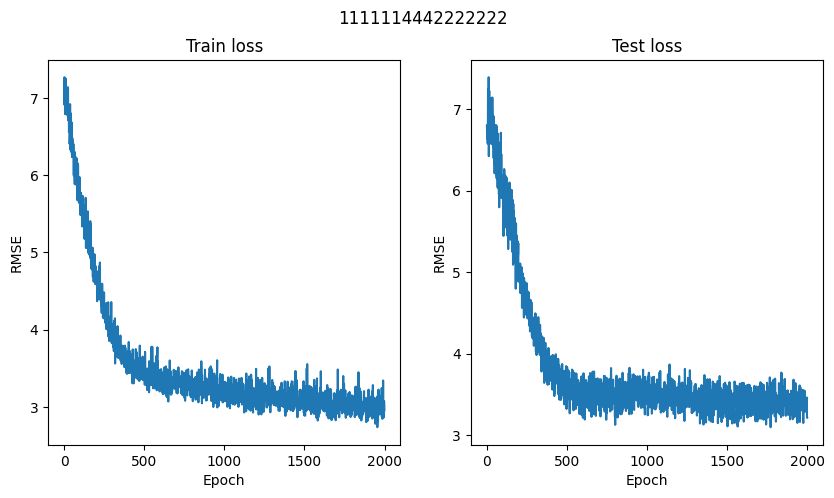

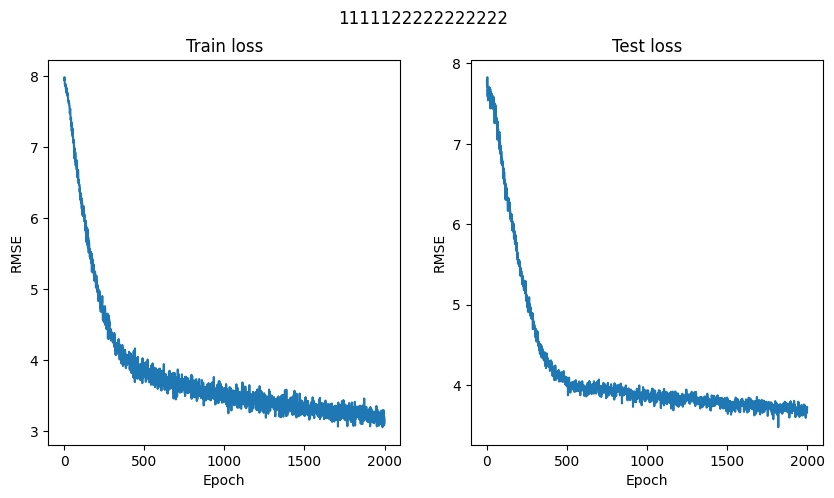

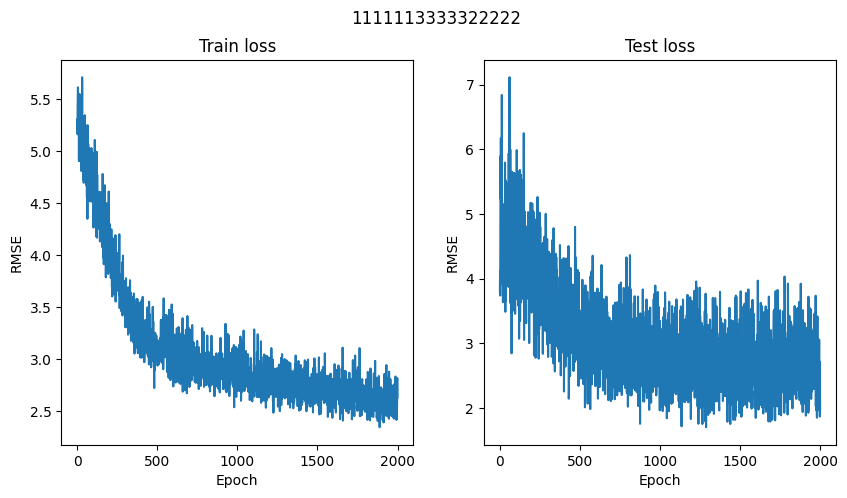

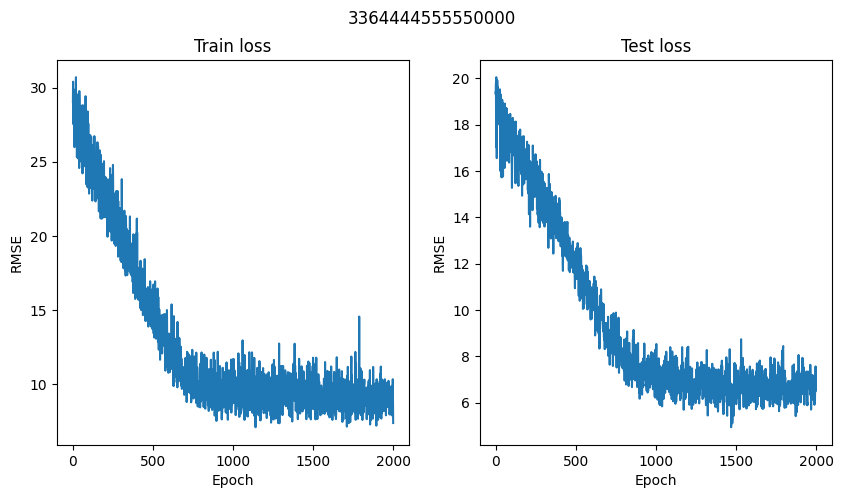

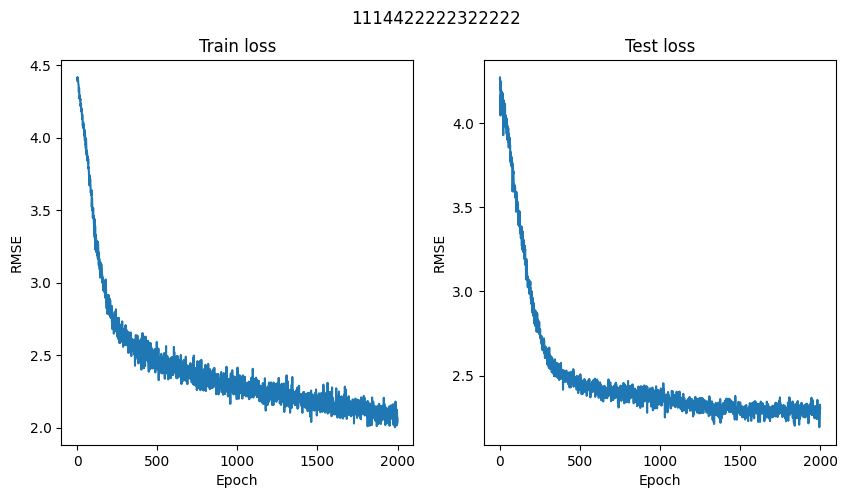

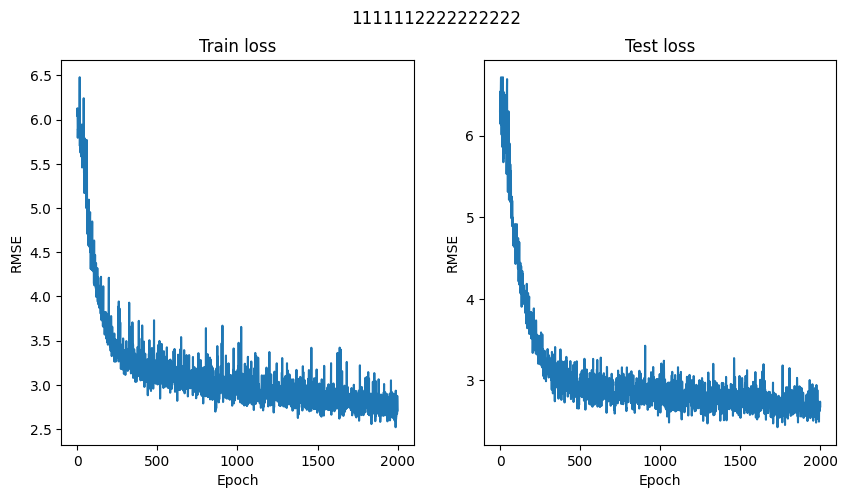

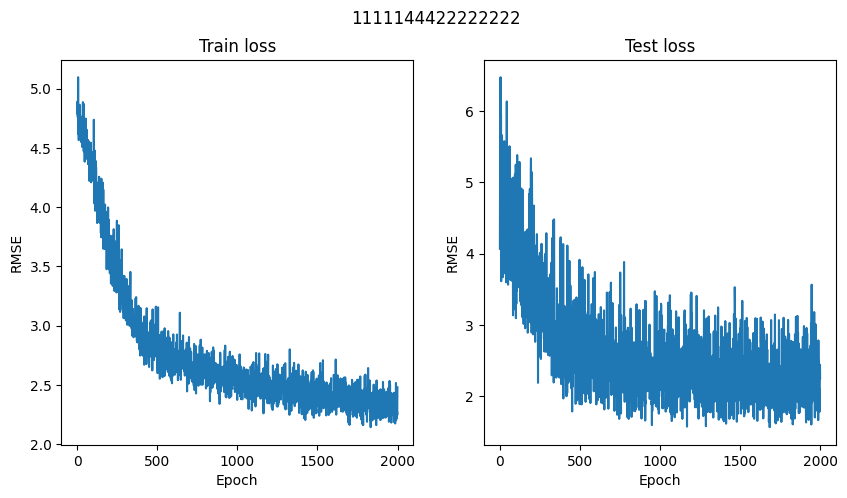

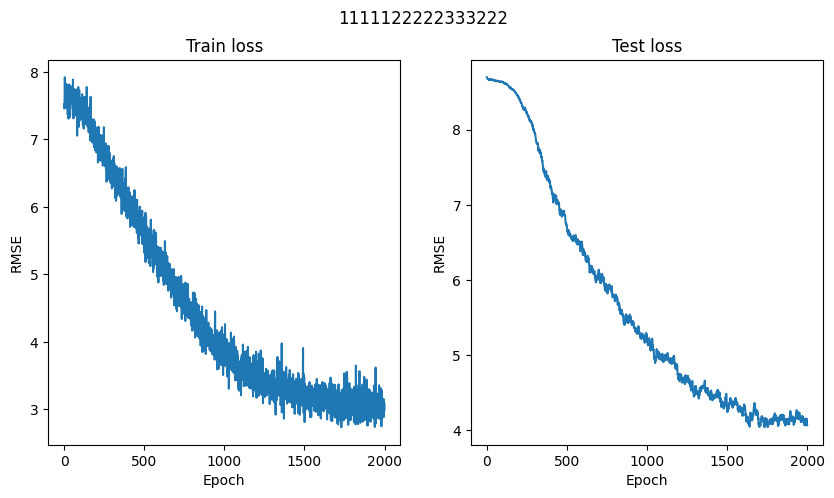

In [109]:
summary = []

os.makedirs(folder, exist_ok=True) 
writer = pd.ExcelWriter(folder+'results.xlsx',engine='xlsxwriter')  

b_size = 256

for o in range(len(data)):

    if not ((str(data[o][2]) in soil_stack)):
        continue
    
    print(data[o][1].Cycle.unique())
    # Разбиваем данные кластера на обучающую и тестовую выборки
    train, test = train_test_split(data[o][1], test_size=0.2, random_state=42, shuffle=True)

    print(test.shape)

    # Формируем обучающий и тестовый датасеты
    train_dataset = GTMDataset(train, stand=True)
    test_dataset = GTMDataset(test, stand=True)

    # Формируем загрузчики
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=b_size, shuffle=True, drop_last=False)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=b_size, shuffle=True,  drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер
    model = NeuralNet().to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr= 0.0001, weight_decay=1e-2) # 1e-3

    # Количество эпох обучения
    n_epochs = 2000

    train_loss_epoch_mean = []
    test_loss_epoch_mean = []


    best_test_loss= 2500
    for epoch in tqdm.tqdm(range(n_epochs)):

        # Обучение
        train_loss = 0
        model.train()


        for i, (x, y, _) in enumerate(train_dataloader):

            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad()

            pred = model(x)
            loss = torch.sqrt(loss_fn(pred, y))

            loss.backward()
            optimizer.step()

            train_loss += loss.detach().cpu().numpy()

        train_loss_epoch_mean.append(train_loss/(i+1))

        # Тест
        test_loss = 0
        model.eval()
        with torch.no_grad():
            for j, (x, y, _) in enumerate(test_dataloader):

                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

                pred = model(x)

                # print(pred)
                loss = torch.sqrt(loss_fn(pred, y)) 
                test_loss += loss.detach().cpu().numpy()
        
        if test_loss < best_test_loss: # если текущий результат лучше лучшего, то запоминаем модель
            best_test_loss = test_loss
            best_model = model # запоминаем модель на случай переобучения
            best_epoch = epoch


        test_loss_epoch_mean.append(test_loss/(j+1))

    # График лосс-функции обучения и теста
    figure, axis = plt.subplots(1, 2, figsize=(10, 5))
    axis[0].plot(train_loss_epoch_mean)
    axis[0].set_title('Train loss')
    axis[0].set(xlabel='Epoch', ylabel='RMSE')
    axis[1].plot(test_loss_epoch_mean)
    axis[1].set_title('Test loss')
    axis[1].set(xlabel='Epoch', ylabel='RMSE')
    figure.suptitle(str(data[o][2]))

    figure.savefig(folder+str(data[o][0])+'_'+str(data[o][2])+'.png')

    # Расчёт метрик

    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    best_model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):
            
            x= x.to(device, non_blocking=True)

            pred = best_model(x)
            pred = pred.cpu()

            loss_rmse = torch.sqrt(loss_fn(pred, y))

            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data[o][2]), index=False)

    torch.save(best_model.state_dict(), folder + str(data[o][2]) + '.pt')

    print(str(o+1) + '.')
    print("Best epoch: ", best_epoch)
    print('DM = %i' %data[o][1]['Mark_num'].unique().shape[0])
    print('Rows = %i' %data[o][1].shape[0])
    print('Train rows = %i' %train.shape[0])
    print('Test rows = %i' %test.shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data[o][2]), data[o][1]['Mark_num'].unique().shape[0], data[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'summary.xlsx')
writer._save()

# Тестирование модели

## Загрузка данных

In [110]:
def prepare_data_11(filt_by_distance = None): # подготовка для тестирования только на 11 цикле

    data = pd.read_csv(ROOT_DIR)

    data = data[data.Cycle == 'XI'] # берем только строки где цикл == 11 циклу


    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв
    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))


    return res

def prepare_data_12(filt_by_distance = None): # подготовка для тестирования только на 12 цикле


    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    data = pd.read_csv(ROOT_DIR)

    data = data[data.Cycle == 'XII']

    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв
    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))
        
    return res

def prepare_data_1112(filt_by_distance = None): # подготовка для тестирования на 11 и 12 цикле

    # filt_by_distance - значение для фильтрации строк по близости ДМ к ТС (если значение не указано, то фильтрации не происходит)

    # Загружаем данные для обработки
    data = pd.read_csv(ROOT_DIR)
    
    data = data[(data['Cycle'] == 'XI') | (data['Cycle'] == 'XII')]

    # Имена колонок для входного вектора с информацией о типе почвы
    soil_type_columns = ['SoilType_0','SoilType_05', 'SoilType_1','SoilType_15', 'SoilType_2','SoilType_25', 'SoilType_3','SoilType_35', 'SoilType_4','SoilType_45', 'SoilType_5', 'SoilType_6', 'SoilType_7', 'SoilType_8', 'SoilType_9', 'SoilType_10']
    
    # Формируем датафрейм с даннымии о типах почвы и температурах на 16-и глубинах (для кластеризации)
    X_for_cluster = data[[*soil_type_columns]]

    # Фильтруем по расстоянию
    if filt_by_distance:

        filt = data['Distance'] <= filt_by_distance
        data = data[filt]
        X_for_cluster = X_for_cluster[filt]

    # Запускаем формирование кластеров по уникальным наборам типов почв
    y, cluster_ids, uniques = soil_columns_cluster(X_for_cluster)

    res = []
    for cid, uniq in zip(cluster_ids, uniques):
        uniq = ''.join(map(str, uniq))
        subset = data[y == cid]
        res.append((cid, subset, uniq))


    return res

In [111]:
data11 = prepare_data_11()
data12 = prepare_data_12()
data1112 = prepare_data_1112()  

## Тестирование

#### 11 цикл

In [112]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data11)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data11[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data11[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data11[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data11[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data11[o][1][data11[o][1]['Cycle']=='XI']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data11[o][2]), data11[o][1].Mark_num.unique().shape[0], data11[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_11.xlsx')
writer._save()

4.
DM = 196
R2 = 0.63
RMSE = 3.44
MAE = 2.50


30.
DM = 459
R2 = 0.87
RMSE = 7.17
MAE = 3.85


33.
DM = 497
R2 = 0.74
RMSE = 3.10
MAE = 2.21


37.
DM = 214
R2 = 0.86
RMSE = 4.78
MAE = 2.95


42.
DM = 360
R2 = 0.86
RMSE = 13.58
MAE = 7.73


43.
DM = 363
R2 = 0.77
RMSE = 2.93
MAE = 2.26


93.
DM = 219
R2 = 0.38
RMSE = 2.94
MAE = 2.10


165.
DM = 65
R2 = 0.62
RMSE = 8.74
MAE = 4.79




#### 12 цикл

In [114]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data12)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data12[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data12[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data12[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data12[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data12[o][1][data12[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data12[o][2]), data12[o][1][data12[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0], data12[o][1].shape[0], res_r2, res_rmse, res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_12.xlsx')
writer._save()

4.
DM = 280
R2 = 0.48
RMSE = 4.02
MAE = 3.19


32.
DM = 363
R2 = 0.57
RMSE = 5.72
MAE = 4.51


35.
DM = 485
R2 = 0.81
RMSE = 3.07
MAE = 2.27


38.
DM = 203
R2 = 0.71
RMSE = 3.37
MAE = 2.53


44.
DM = 386
R2 = 0.87
RMSE = 9.31
MAE = 5.07


45.
DM = 352
R2 = 0.25
RMSE = 5.30
MAE = 4.77


94.
DM = 221
R2 = 0.60
RMSE = 20.95
MAE = 5.49


168.
DM = 63
R2 = 0.67
RMSE = 7.61
MAE = 3.72




#### 11 + 12 циклы

In [115]:
summary = []
writer = pd.ExcelWriter(folder+'reg_results.xlsx',engine='xlsxwriter')  
all_pred_11_cycle = pd.DataFrame(columns=['DM', 'Cycle','Actual', 'Predicted'])

for o in range(len(data1112)):

    # Делаем прогноз только для тех кластеров, для которых есть обученная модель и для которых есть значения для 11-го цикла
    if not ((str(data1112[o][2]) in soil_stack)):
        continue


    # Формируем обучающий и тестовый датасеты
    test_dataset = GTMDataset(data1112[o][1],stand=True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1024, drop_last=False)

    # Формируем модель, лосс-функцию и оптимайзер

    loss_fn = nn.MSELoss()

    # Загружаем обученную модель для рассматриваемого набора типов почв (кластера)
    model = NeuralNet()
    model.load_state_dict(torch.load(folder+str(data1112[o][2])+'.pt', weights_only=True))
    model.eval()

    rmse = []
    mae = []
    r2 = []
    
    all_y = []
    all_pred = []
    all_x = []
    all_dm = []
    all_cycles = []

    with torch.no_grad():

        for j, (x, y, z) in enumerate(test_dataloader):

            pred = model(x)
            loss_rmse = torch.sqrt(loss_fn(pred, y))
            loss_mae = mean_absolute_error(y, pred)
            loss_r2 = r2_score(y, pred)

            all_pred += pred.reshape(-1).detach().tolist()
            all_y += y.reshape(-1).detach().tolist()
            all_dm += list(z[0])
            all_cycles += list(z[1])

            rmse.append(loss_rmse.detach().numpy())
            mae.append(loss_mae)
            r2.append(loss_r2)

    res_rmse = sum(rmse)/len(rmse)
    res_mae = sum(mae)/len(mae)
    res_r2 = sum(r2)/len(r2)

    results = pd.DataFrame(np.concatenate([np.array([all_dm]).T,np.array([all_cycles]).T,np.array([all_y]).T,np.array([all_pred]).T],axis=1), columns=['DM', 'Cycle','Actual', 'Predicted'])
    results.to_excel(writer,sheet_name=str(data1112[o][2]), index=False)
    all_pred_11_cycle = pd.concat([all_pred_11_cycle, results])

    print(str(o+1) + '.')
    print('DM = %i' %data1112[o][1][data1112[o][1]['Cycle']=='XII']['Mark_num'].unique().shape[0])
    print('R2 = %.2f' %res_r2)
    print('RMSE = %.2f' %res_rmse)
    print('MAE = %.2f' %res_mae)
    print('\n')

    summary.append([str(data1112[o][2]),
                    data1112[o][1].Mark_num.unique().shape[0], 
                    data1112[o][1].shape[0],
                    res_r2, 
                    res_rmse, 
                    res_mae])

df = pd.DataFrame(summary, columns=['Soil_types', 'DM', 'Rows', 'R2', 'RMSE', 'MAE'])
df.sort_values('Rows', ascending=False)
df.to_excel(folder + 'reg_summary_1112.xlsx')
writer._save()

4.
DM = 280
R2 = 0.54
RMSE = 3.79
MAE = 2.91


32.
DM = 363
R2 = 0.83
RMSE = 6.57
MAE = 4.14


35.
DM = 485
R2 = 0.78
RMSE = 3.09
MAE = 2.24


38.
DM = 203
R2 = 0.83
RMSE = 4.15
MAE = 2.74


44.
DM = 386
R2 = 0.87
RMSE = 11.57
MAE = 6.35


45.
DM = 352
R2 = 0.52
RMSE = 4.26
MAE = 3.50


94.
DM = 221
R2 = 0.60
RMSE = 14.99
MAE = 3.81


168.
DM = 63
R2 = 0.64
RMSE = 8.20
MAE = 4.27


